## Round 5 — Cross-Group Relationship Analysis

Compares the 10 product groups as group-level time series, looking for correlations, lead-lag relationships, cointegration, and common factors.

In [1]:
import math
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

from pathlib import Path
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf

import prosperity4
from prosperity4.utils.dataloader import load_trading_data, convert_timestamp

plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [2]:
REPO_ROOT   = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round5" / "data"
ROUND_NUM   = 5
DAYS        = [2, 3, 4]

GROUPS = {
    "Galaxy Sounds":   ["GALAXY_SOUNDS_DARK_MATTER", "GALAXY_SOUNDS_BLACK_HOLES",
                        "GALAXY_SOUNDS_PLANETARY_RINGS", "GALAXY_SOUNDS_SOLAR_WINDS",
                        "GALAXY_SOUNDS_SOLAR_FLAMES"],
    "Sleep Pods":      ["SLEEP_POD_SUEDE", "SLEEP_POD_LAMB_WOOL", "SLEEP_POD_POLYESTER",
                        "SLEEP_POD_NYLON", "SLEEP_POD_COTTON"],
    "Microchips":      ["MICROCHIP_CIRCLE", "MICROCHIP_OVAL", "MICROCHIP_SQUARE",
                        "MICROCHIP_RECTANGLE", "MICROCHIP_TRIANGLE"],
    "Pebbles":         ["PEBBLES_XS", "PEBBLES_S", "PEBBLES_M", "PEBBLES_L", "PEBBLES_XL"],
    "Robots":          ["ROBOT_VACUUMING", "ROBOT_MOPPING", "ROBOT_DISHES",
                        "ROBOT_LAUNDRY", "ROBOT_IRONING"],
    "UV Visors":       ["UV_VISOR_YELLOW", "UV_VISOR_AMBER", "UV_VISOR_ORANGE",
                        "UV_VISOR_RED", "UV_VISOR_MAGENTA"],
    "Translators":     ["TRANSLATOR_SPACE_GRAY", "TRANSLATOR_ASTRO_BLACK",
                        "TRANSLATOR_ECLIPSE_CHARCOAL", "TRANSLATOR_GRAPHITE_MIST",
                        "TRANSLATOR_VOID_BLUE"],
    "Panels":          ["PANEL_1X2", "PANEL_2X2", "PANEL_1X4", "PANEL_2X4", "PANEL_4X4"],
    "Oxygen Shakes":   ["OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_EVENING_BREATH",
                        "OXYGEN_SHAKE_MINT", "OXYGEN_SHAKE_CHOCOLATE", "OXYGEN_SHAKE_GARLIC"],
    "Snack Packs":     ["SNACKPACK_CHOCOLATE", "SNACKPACK_VANILLA", "SNACKPACK_PISTACHIO",
                        "SNACKPACK_STRAWBERRY", "SNACKPACK_RASPBERRY"],
}
GROUP_NAMES = list(GROUPS.keys())

data      = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape)
print("Trades Shape :", trades_df.shape)
display(prices_df.head(3))

Prices Shape : (1500000, 17)
Trades Shape : (35385, 8)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PEBBLES_L,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990.0,45.0,NaN,NaN,10008,36,10010.0,45.0,NaN,NaN,10000.0,0.0
2,2,0,UV_VISOR_RED,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0


### Group-Level Price Series

For each group we compute the **equal-weighted average mid-price** across its five products, aligned to a shared continuous timestamp grid.  We also compute the z-score-normalised version (mean=0, std=1) so all groups can be plotted on the same scale.

In [3]:
# Build a common continuous timestamp index (same logic as convert_timestamp)
day_map = {2: 0, 3: 1_000_000, 4: 2_000_000}
prices_df = prices_df.copy()
prices_df["t"] = prices_df["day"].map(day_map) + prices_df["timestamp"]

all_t = sorted(prices_df["t"].unique())

group_mid: dict[str, pd.Series] = {}

for group, symbols in GROUPS.items():
    member_series = []
    for sym in symbols:
        s = (
            prices_df[prices_df["product"] == sym]
            .set_index("t")["mid_price"]
            .reindex(all_t, method="ffill")
        )
        member_series.append(s)
    # equal-weight average across the group's products
    group_mid[group] = pd.concat(member_series, axis=1).mean(axis=1)

# DataFrame: rows = timestamps, columns = group names
mid_df = pd.DataFrame(group_mid, index=all_t)
mid_df.index.name = "t"

# Normalised (z-score per group)
norm_df = (mid_df - mid_df.mean()) / mid_df.std()

print("Group mid-price matrix shape:", mid_df.shape)
display(mid_df.head())

Group mid-price matrix shape: (30000, 10)


,Galaxy Sounds,Sleep Pods,Microchips,Pebbles,Robots,UV Visors,Translators,Panels,Oxygen Shakes,Snack Packs
t,,,,,,,,,,
0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
100,9997.5,10000.3,9998.1,10000.1,9993.7,10004.2,10002.3,9994.2,10001.1,9999.9
200,10002.5,9996.1,9998.9,10000.1,10000.7,10008.1,10001.1,10002.7,10001.7,10000.7
300,10005.3,9998.9,9993.9,10000.0,10002.0,10012.9,9997.5,9999.8,10006.1,9999.9
400,10005.3,9999.9,9995.3,10000.0,9996.9,10011.7,10001.7,10002.3,10001.5,9998.1


### Normalised Mid-Price: All Groups Over Time

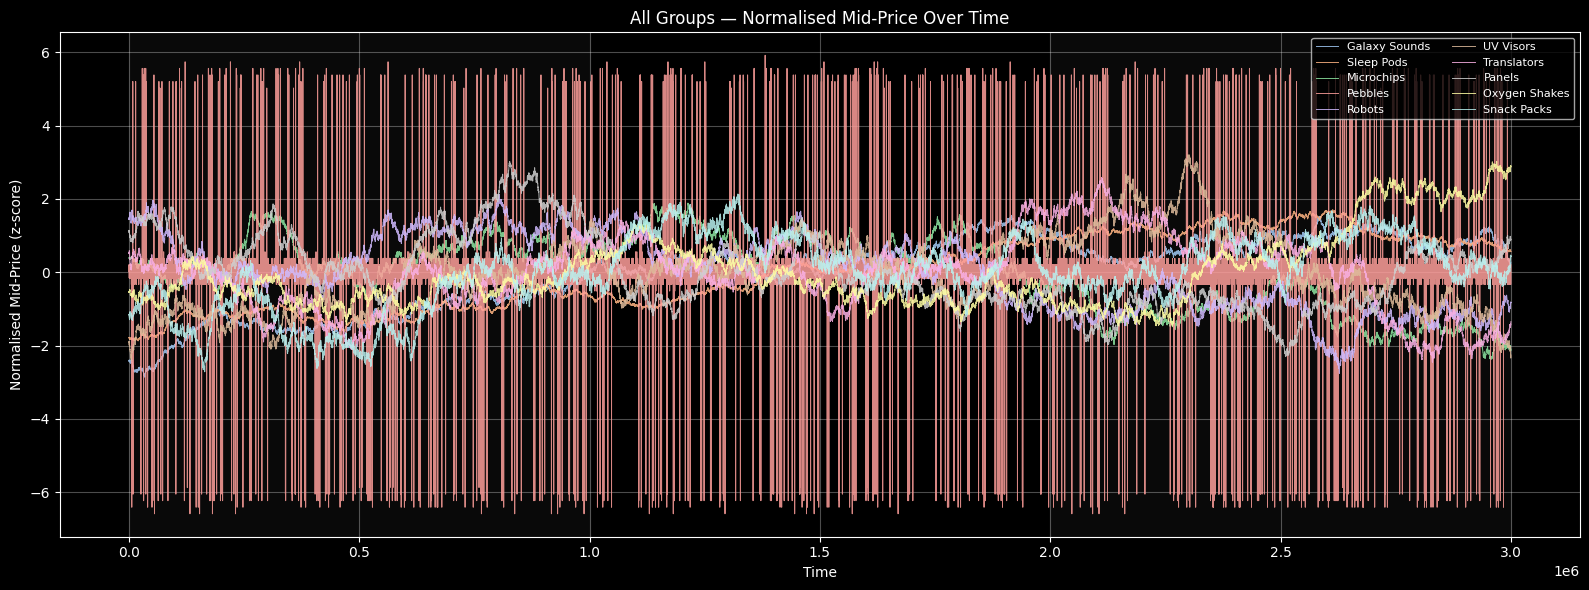

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
for col in norm_df.columns:
    ax.plot(norm_df.index, norm_df[col], linewidth=0.7, alpha=0.85, label=col)

# shade day boundaries
for i, (day, day_t) in enumerate([(2, 0), (3, 1_000_000), (4, 2_000_000)]):
    if i % 2 == 0:
        ax.axvspan(day_t, day_t + 999_900, alpha=0.07, color="grey", zorder=0)

ax.set_xlabel("Time")
ax.set_ylabel("Normalised Mid-Price (z-score)")
ax.set_title("All Groups — Normalised Mid-Price Over Time")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

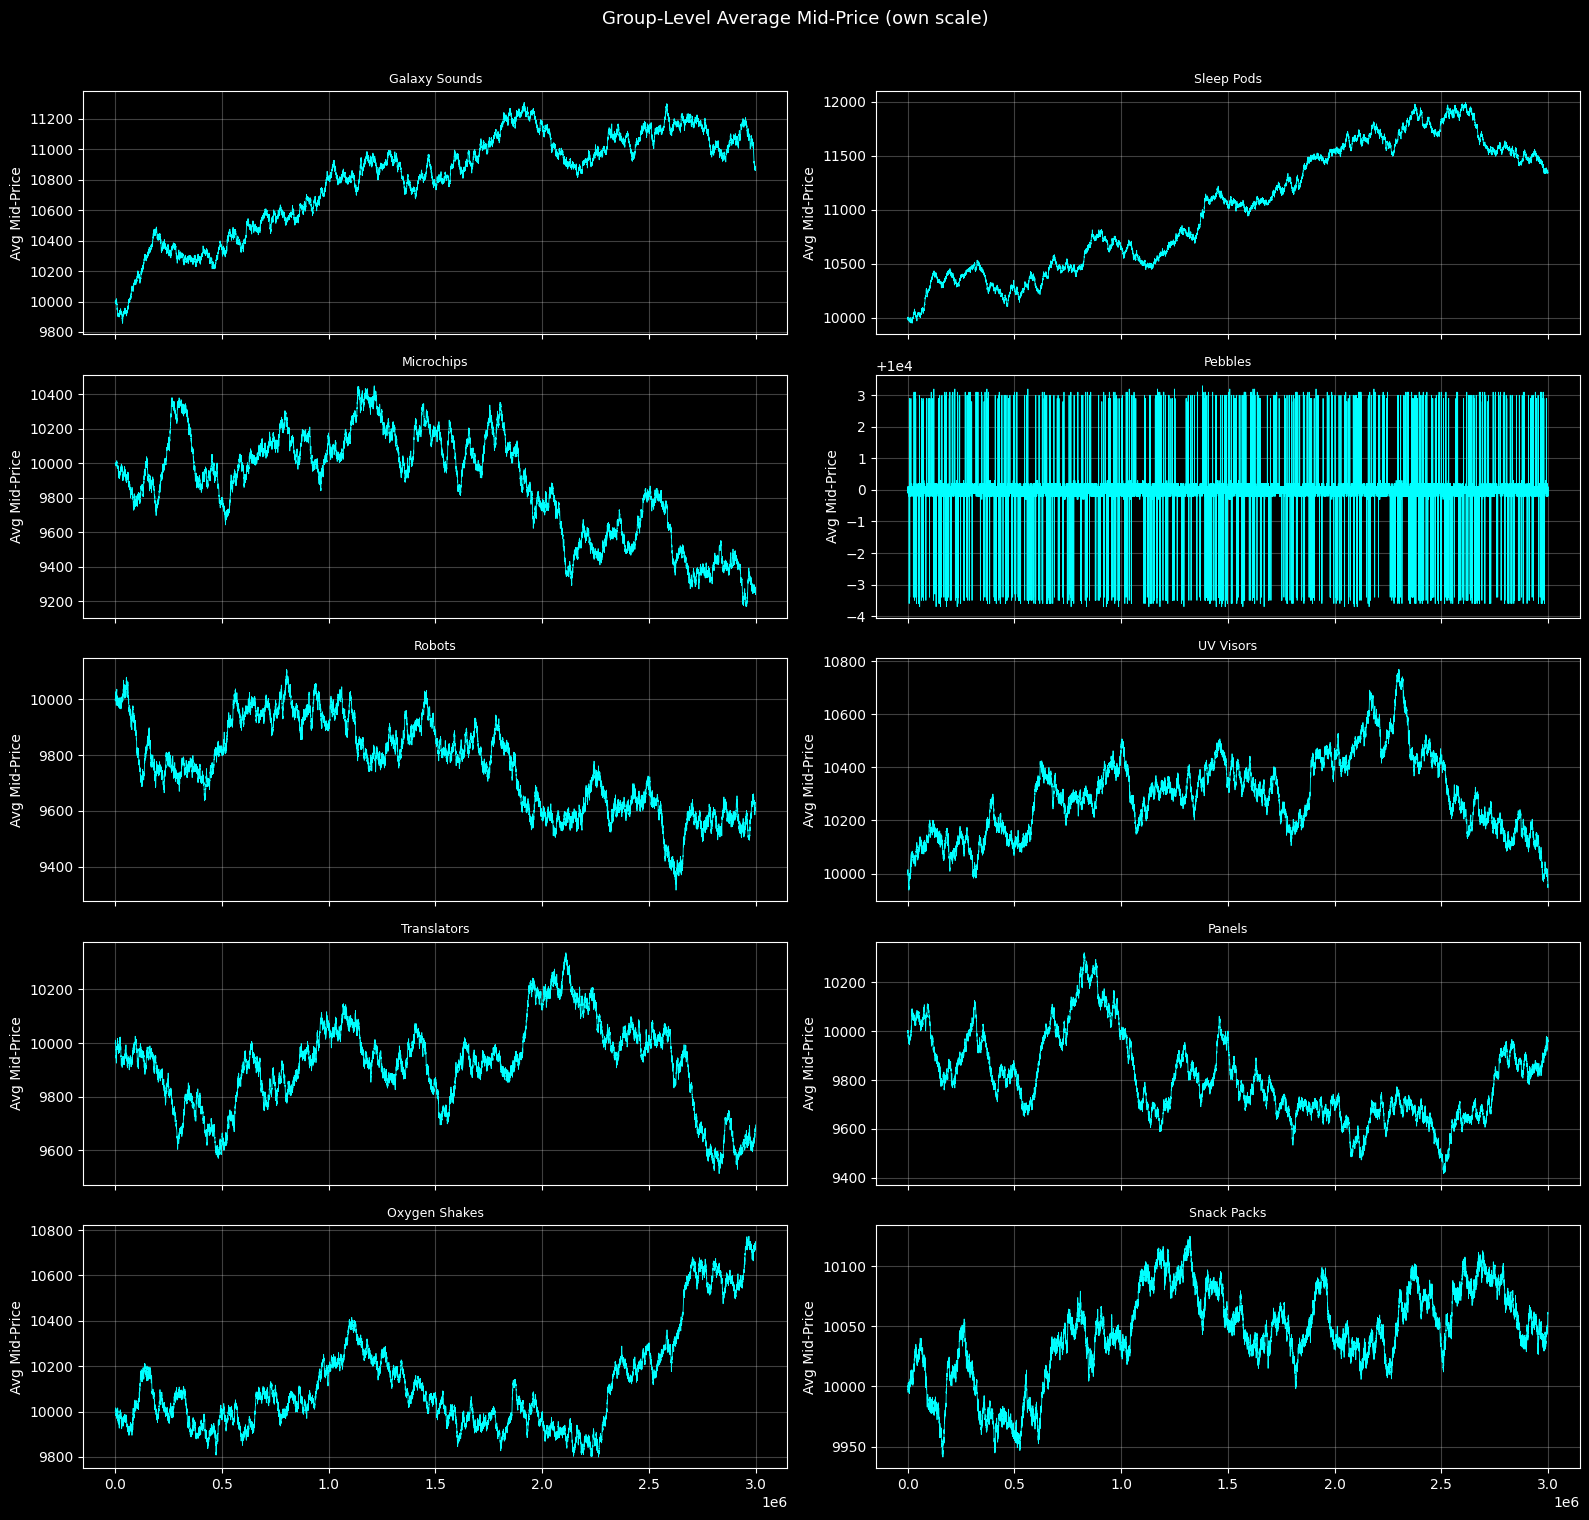

In [5]:
ncols = 2
nrows = math.ceil(len(GROUP_NAMES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), sharex=True)
axes = axes.flatten()

for ax, group in zip(axes, GROUP_NAMES):
    ax.plot(mid_df.index, mid_df[group], linewidth=0.6, color="cyan")
    ax.set_title(group, fontsize=9)
    ax.set_ylabel("Avg Mid-Price")
    ax.grid(True, alpha=0.25)

for ax in axes[len(GROUP_NAMES):]:
    ax.set_visible(False)

fig.suptitle("Group-Level Average Mid-Price (own scale)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Returns

Tick-by-tick first differences of the group mid-price series.

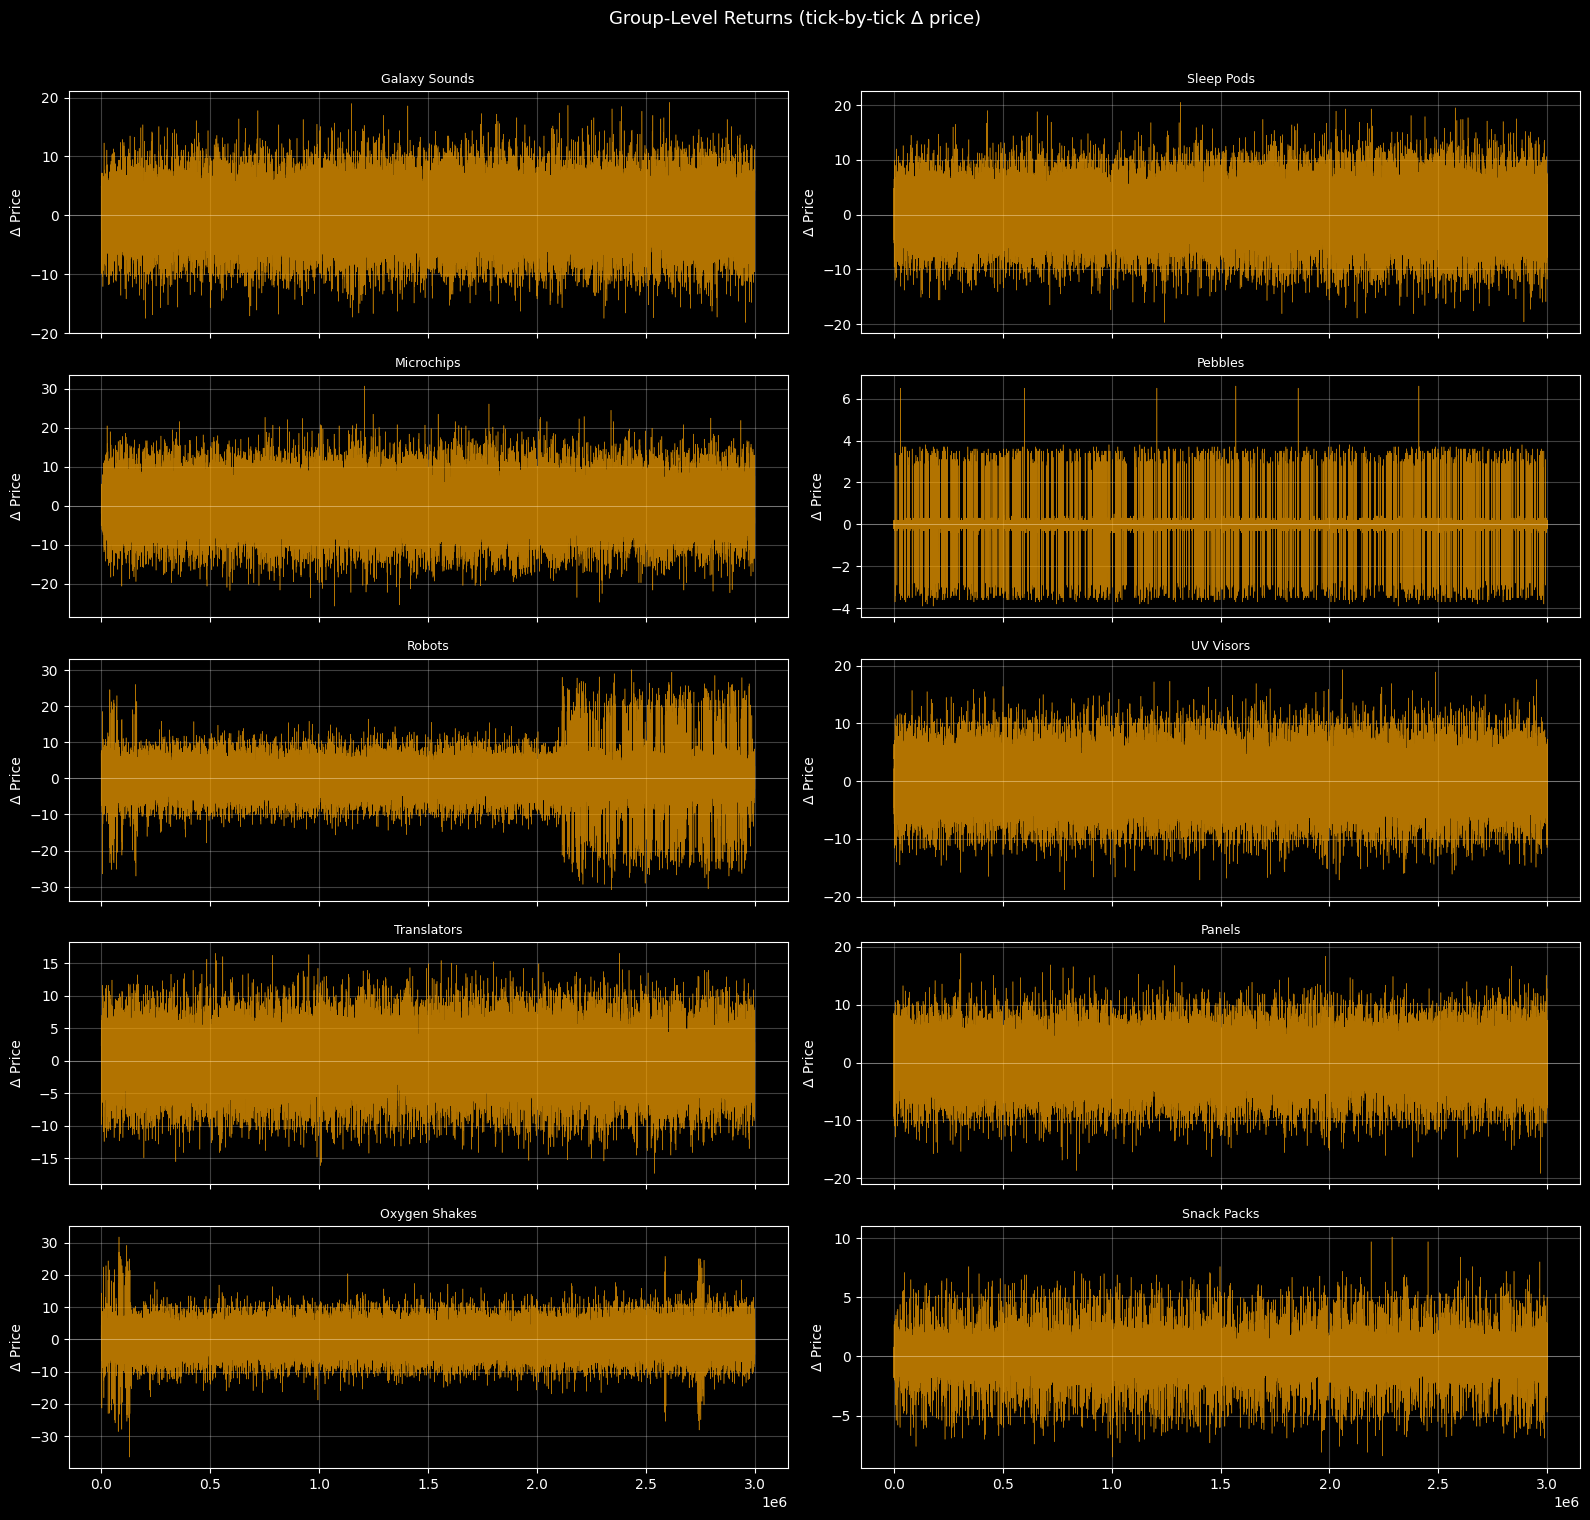

In [6]:
ret_df = mid_df.diff().dropna()

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), sharex=True)
axes = axes.flatten()

for ax, group in zip(axes, GROUP_NAMES):
    ax.plot(ret_df.index, ret_df[group], linewidth=0.4, alpha=0.7, color="orange")
    ax.set_title(group, fontsize=9)
    ax.set_ylabel("Δ Price")
    ax.axhline(0, linewidth=0.4, alpha=0.5, color="white")
    ax.grid(True, alpha=0.25)

for ax in axes[len(GROUP_NAMES):]:
    ax.set_visible(False)

fig.suptitle("Group-Level Returns (tick-by-tick Δ price)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Static Correlation Analysis

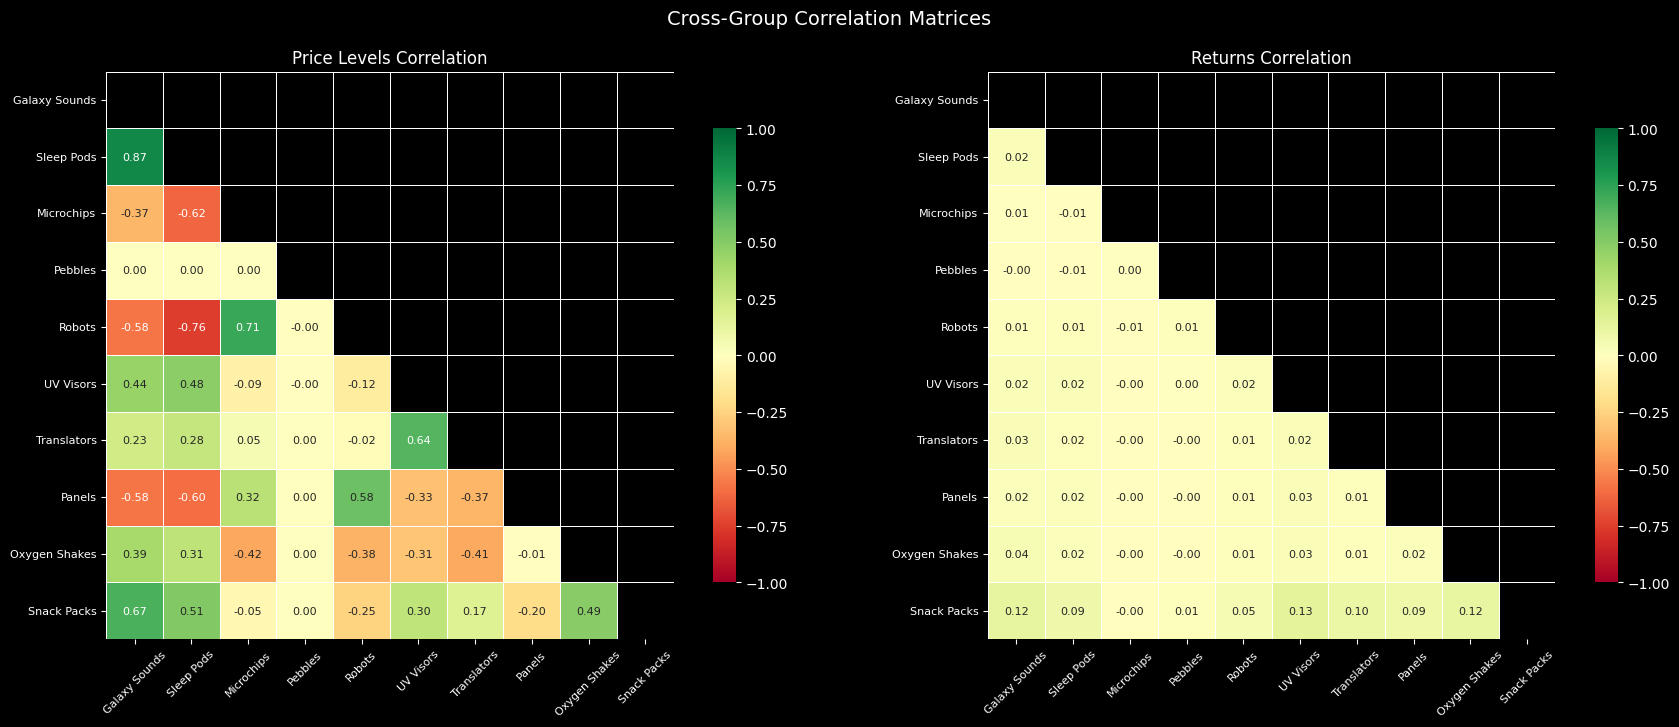


Top 5 most correlated pairs (returns):
  UV Visors × Snack Packs: r = 0.1343
  Galaxy Sounds × Snack Packs: r = 0.1220
  Oxygen Shakes × Snack Packs: r = 0.1161
  Translators × Snack Packs: r = 0.1003
  Panels × Snack Packs: r = 0.0914

Top 5 least correlated pairs (returns):
  Pebbles × Translators: r = -0.0004
  Microchips × Pebbles: r = 0.0004
  Pebbles × UV Visors: r = 0.0013
  Pebbles × Oxygen Shakes: r = -0.0014
  Microchips × Panels: r = -0.0018


In [7]:
corr_levels  = mid_df.corr()
corr_returns = ret_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr, title in [
    (axes[0], corr_levels,  "Price Levels Correlation"),
    (axes[1], corr_returns, "Returns Correlation"),
]:
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, mask=mask,
        cmap="RdYlGn", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.5, square=True,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Cross-Group Correlation Matrices", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 5 most correlated pairs (returns):")
pairs = []
for a, b in itertools.combinations(GROUP_NAMES, 2):
    pairs.append((a, b, corr_returns.loc[a, b]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs[:5]:
    print(f"  {a} × {b}: r = {r:.4f}")

print("\nTop 5 least correlated pairs (returns):")
for a, b, r in sorted(pairs, key=lambda x: abs(x[2]))[:5]:
    print(f"  {a} × {b}: r = {r:.4f}")

---
## Rolling Pairwise Correlations

50 000-tick rolling window applied to the top 6 return-correlated pairs.

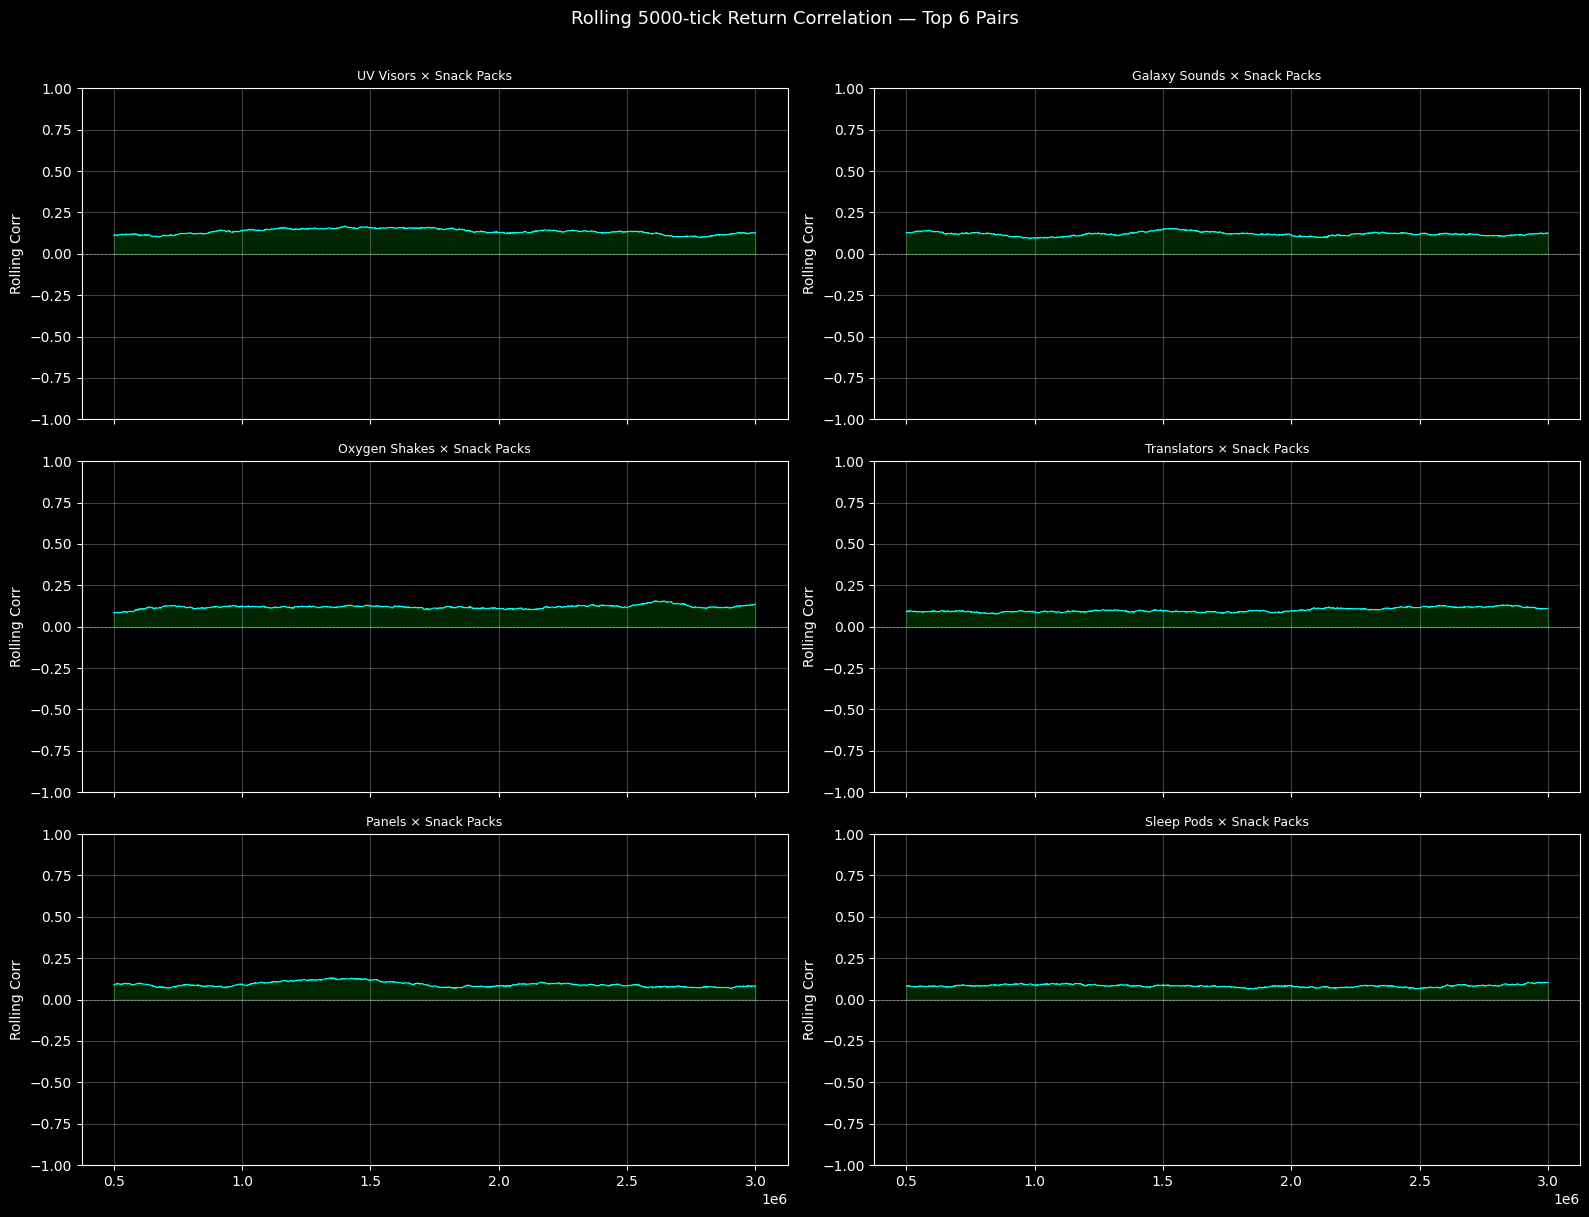

In [8]:
ROLL_WINDOW = 5_000   # ~5 000 ticks

top_pairs = [(a, b) for a, b, _ in pairs[:6]]

ncols_rc = 2
nrows_rc = math.ceil(len(top_pairs) / ncols_rc)

fig, axes = plt.subplots(nrows_rc, ncols_rc, figsize=(16, 4 * nrows_rc), sharex=True)
axes = axes.flatten()

for ax, (a, b) in zip(axes, top_pairs):
    roll_corr = ret_df[a].rolling(ROLL_WINDOW).corr(ret_df[b])
    ax.plot(roll_corr.index, roll_corr.values, linewidth=0.7, color="cyan")
    ax.axhline(0, linewidth=0.5, linestyle="--", alpha=0.5, color="white")
    ax.fill_between(roll_corr.index, 0, roll_corr.values,
                    where=(roll_corr.values > 0), color="lime",  alpha=0.15)
    ax.fill_between(roll_corr.index, 0, roll_corr.values,
                    where=(roll_corr.values < 0), color="red",   alpha=0.15)
    ax.set_title(f"{a} × {b}", fontsize=9)
    ax.set_ylabel("Rolling Corr")
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.25)

for ax in axes[len(top_pairs):]:
    ax.set_visible(False)

fig.suptitle(f"Rolling {ROLL_WINDOW}-tick Return Correlation — Top 6 Pairs", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Lead-Lag Analysis

Cross-correlation function (CCF) at lags −100 to +100 ticks for every pair.  
A peak at lag **k > 0** means **column group leads row group** by k ticks.

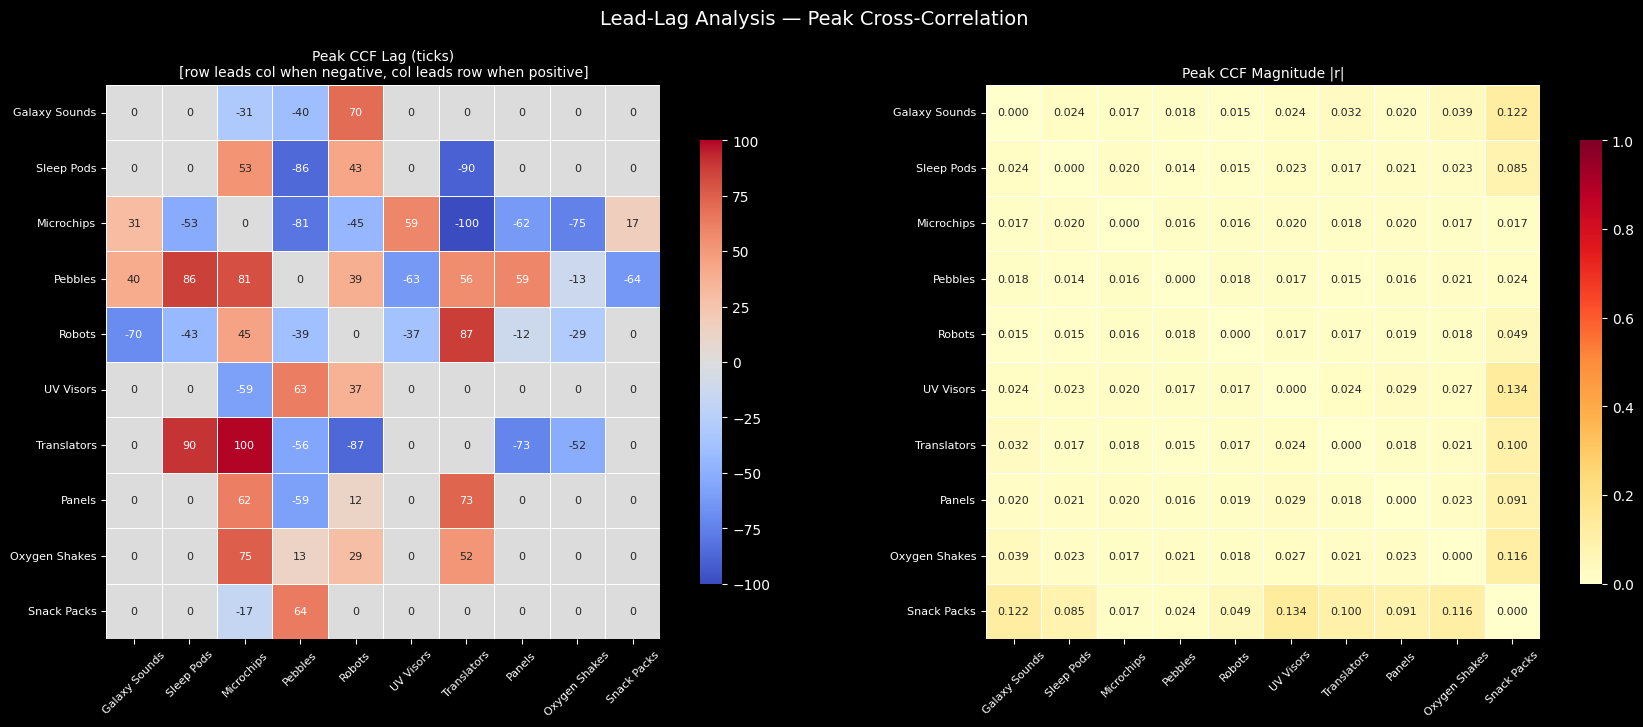

In [10]:
MAX_LAG = 100
lags    = np.arange(-MAX_LAG, MAX_LAG + 1)

def cross_corr(x: pd.Series, y: pd.Series, max_lag: int) -> np.ndarray:
    """CCF of x (lag) vs y.  Positive lag: x leads y."""    
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    n = len(x)
    vals = []
    for lag in range(-max_lag, max_lag + 1):
        if lag >= 0:
            c = np.dot(x.iloc[:n - lag].values, y.iloc[lag:].values) / n
        else:
            c = np.dot(x.iloc[-lag:].values, y.iloc[:n + lag].values) / n
        vals.append(c)
    return np.array(vals)

# Build a matrix of peak-lag per pair
peak_lag_matrix  = pd.DataFrame(np.zeros((len(GROUP_NAMES), len(GROUP_NAMES))),
                                index=GROUP_NAMES, columns=GROUP_NAMES)
peak_corr_matrix = peak_lag_matrix.copy()

for a in GROUP_NAMES:
    for b in GROUP_NAMES:
        if a == b:
            continue
        ccf = cross_corr(ret_df[a], ret_df[b], MAX_LAG)
        best_idx = np.argmax(np.abs(ccf))
        peak_lag_matrix.loc[a, b]  = lags[best_idx]
        peak_corr_matrix.loc[a, b] = ccf[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(peak_lag_matrix, ax=axes[0], cmap="coolwarm", center=0,
            annot=True, fmt=".0f", annot_kws={"size": 8},
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
axes[0].set_title("Peak CCF Lag (ticks)\n[row leads col when negative, col leads row when positive]",
                  fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

sns.heatmap(peak_corr_matrix.abs(), ax=axes[1], cmap="YlOrRd", vmin=0, vmax=1,
            annot=True, fmt=".3f", annot_kws={"size": 8},
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
axes[1].set_title("Peak CCF Magnitude |r|", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Lead-Lag Analysis — Peak Cross-Correlation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

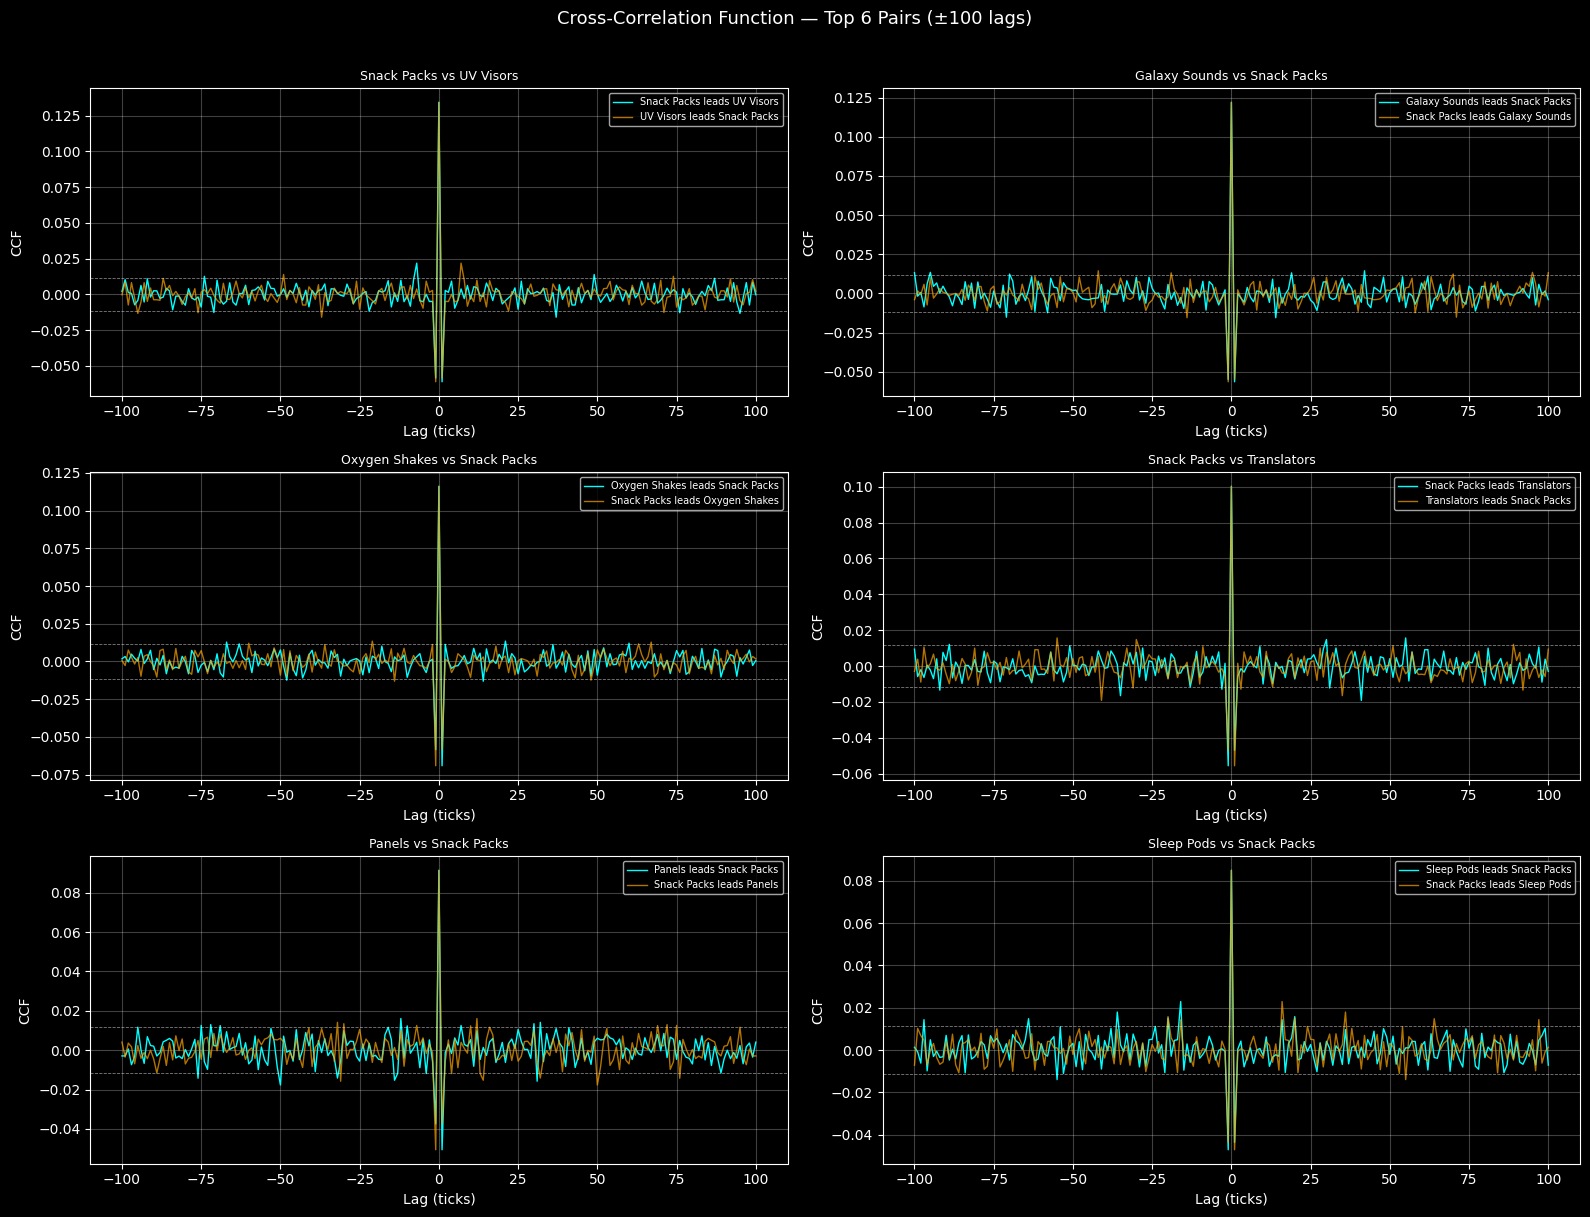

In [11]:
# CCF curves for the 6 pairs with the strongest peak correlation magnitude
pair_strengths = []
for a in GROUP_NAMES:
    for b in GROUP_NAMES:
        if a >= b:   # skip diagonal and duplicates
            continue
        pair_strengths.append((a, b, abs(peak_corr_matrix.loc[a, b])))

pair_strengths.sort(key=lambda x: x[2], reverse=True)
top_ccf_pairs = [(a, b) for a, b, _ in pair_strengths[:6]]

ncols_ccf = 2
nrows_ccf = math.ceil(len(top_ccf_pairs) / ncols_ccf)
fig, axes = plt.subplots(nrows_ccf, ncols_ccf, figsize=(16, 4 * nrows_ccf))
axes = axes.flatten()

sig_band = 2 / np.sqrt(len(ret_df))   # ≈95% significance band

for ax, (a, b) in zip(axes, top_ccf_pairs):
    ccf_ab = cross_corr(ret_df[a], ret_df[b], MAX_LAG)
    ccf_ba = cross_corr(ret_df[b], ret_df[a], MAX_LAG)

    ax.plot(lags, ccf_ab, color="cyan",   linewidth=1.0, label=f"{a} leads {b}")
    ax.plot(lags, ccf_ba, color="orange", linewidth=1.0, alpha=0.7, label=f"{b} leads {a}")
    ax.axhline( sig_band, color="white", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.axhline(-sig_band, color="white", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.axhline(0,          color="grey",  linewidth=0.4, linestyle=":",  alpha=0.5)
    ax.axvline(0,          color="grey",  linewidth=0.4, linestyle=":",  alpha=0.5)
    ax.set_title(f"{a} vs {b}", fontsize=9)
    ax.set_xlabel("Lag (ticks)")
    ax.set_ylabel("CCF")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

for ax in axes[len(top_ccf_pairs):]:
    ax.set_visible(False)

fig.suptitle("Cross-Correlation Function — Top 6 Pairs (±100 lags)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Granger Causality

Tests whether the lagged history of group A helps predict group B's returns beyond B's own lags.  We use maxlag = 5 and report the minimum p-value across lags 1–5.  A low p-value (< 0.05) means **A Granger-causes B** at that lag.

d:\IMC Prosperity 4\Stochastic Bulls\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\IMC Prosperity 4\Stochastic Bulls\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\IMC Prosperity 4\Stochastic Bulls\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\IMC Prosperity 4\Stochastic Bulls\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\IMC Prosperity 4\Stochastic Bulls\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions sh

AttributeError: 'DataFrame' object has no attribute 'applymap'

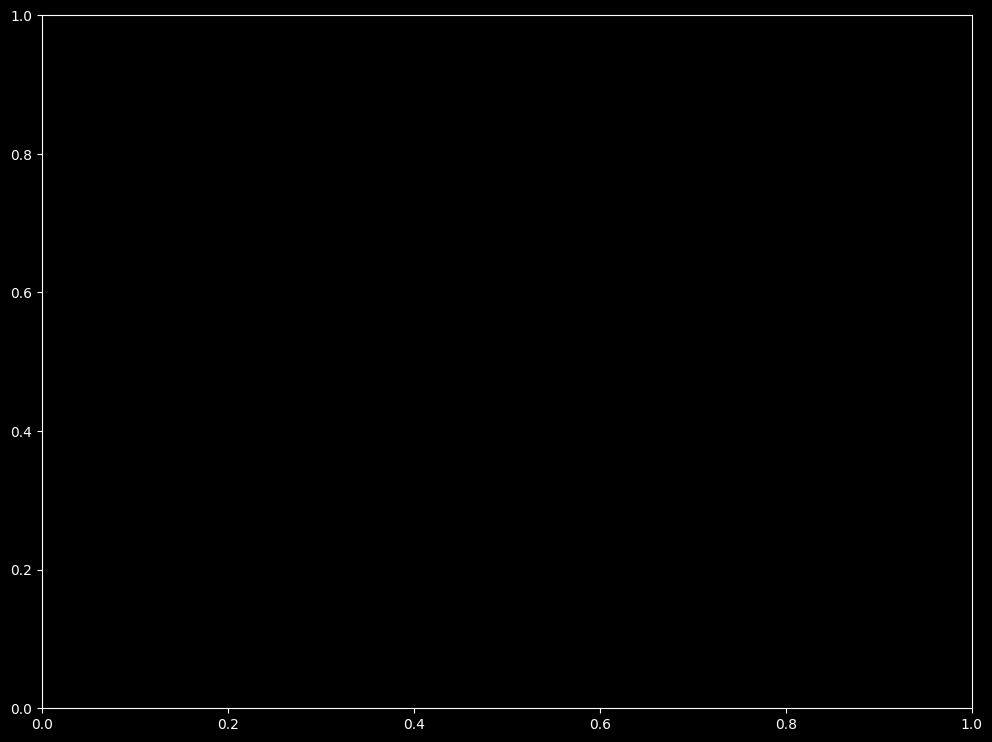

In [12]:
MAX_GC_LAG = 5

# sub-sample to speed up: every 10th tick still gives 300 000 / 10 = 30 000 rows
ret_sub = ret_df.iloc[::10].dropna()

gc_pval = pd.DataFrame(np.nan, index=GROUP_NAMES, columns=GROUP_NAMES)

for a in GROUP_NAMES:
    for b in GROUP_NAMES:
        if a == b:
            continue
        try:
            test_data = ret_sub[[b, a]].dropna()   # [y, x] order for statsmodels
            res = grangercausalitytests(test_data, maxlag=MAX_GC_LAG, verbose=False)
            # minimum p-value across lags
            min_p = min(res[lag][0]["ssr_ftest"][1] for lag in range(1, MAX_GC_LAG + 1))
            gc_pval.loc[a, b] = min_p
        except Exception:
            pass

gc_pval = gc_pval.astype(float)

fig, ax = plt.subplots(figsize=(12, 9))
# Annotate with stars for significance
annot = gc_pval.applymap(lambda p: f"{p:.3f}" if not np.isnan(p) else "—")
sns.heatmap(
    gc_pval, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=0.1, center=0.05,
    annot=annot, fmt="", annot_kws={"size": 7.5},
    linewidths=0.5, square=True, cbar_kws={"shrink": 0.8, "label": "min p-value"},
)
ax.set_title(
    "Granger Causality p-values  (row → col)\n"
    "Green = row Granger-causes col  |  red = no evidence",
    fontsize=11,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

print("\nSignificant Granger relationships (p < 0.05):")
for a in GROUP_NAMES:
    for b in GROUP_NAMES:
        if a == b:
            continue
        p = gc_pval.loc[a, b]
        if not np.isnan(p) and p < 0.05:
            print(f"  {a:20s} → {b:20s}  p = {p:.4f}")

---
## Cointegration Tests (Engle-Granger)

If two group price series are cointegrated they share a common stochastic trend — the spread is stationary and mean-reverts, creating a pairs-trading opportunity.

AttributeError: 'DataFrame' object has no attribute 'applymap'

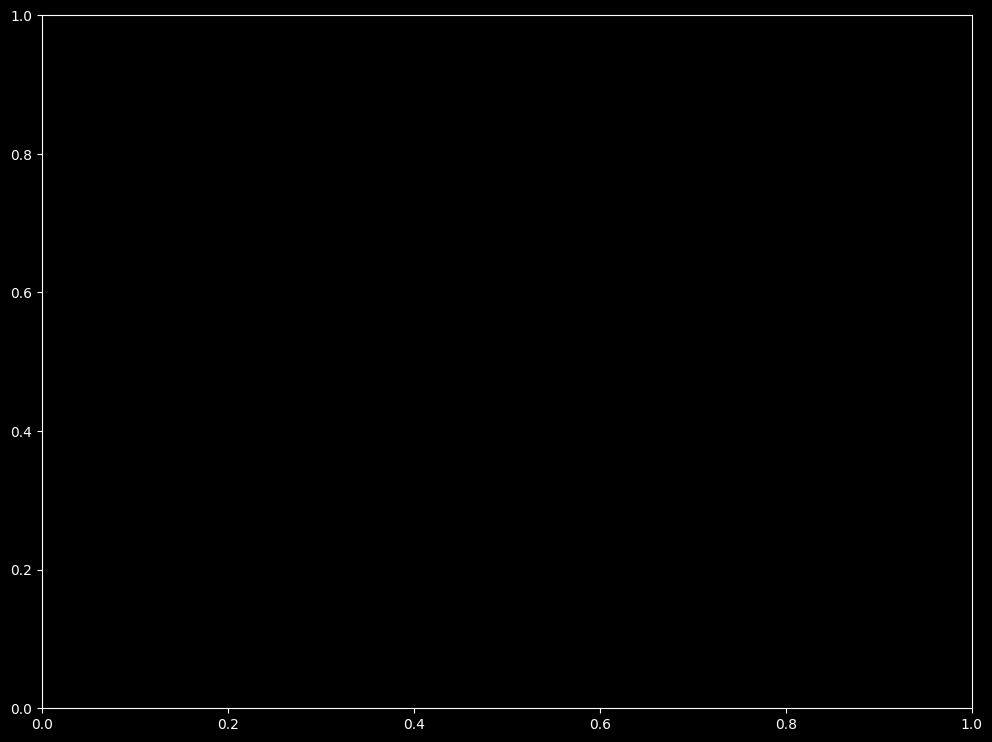

In [13]:
coint_pval = pd.DataFrame(np.nan, index=GROUP_NAMES, columns=GROUP_NAMES)

# Down-sample for speed
mid_sub = mid_df.iloc[::10].dropna()

for a in GROUP_NAMES:
    for b in GROUP_NAMES:
        if a == b:
            continue
        try:
            _, pval, _ = coint(mid_sub[a], mid_sub[b])
            coint_pval.loc[a, b] = pval
        except Exception:
            pass

coint_pval = coint_pval.astype(float)

fig, ax = plt.subplots(figsize=(12, 9))
annot_c = coint_pval.applymap(lambda p: f"{p:.3f}" if not np.isnan(p) else "—")
sns.heatmap(
    coint_pval, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=0.1, center=0.05,
    annot=annot_c, fmt="", annot_kws={"size": 7.5},
    linewidths=0.5, square=True, cbar_kws={"shrink": 0.8, "label": "p-value"},
)
ax.set_title(
    "Engle-Granger Cointegration p-values  (row vs col)\n"
    "Green = cointegrated  |  red = no cointegration",
    fontsize=11,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# Collect cointegrated pairs
coint_pairs = []
for a, b in itertools.combinations(GROUP_NAMES, 2):
    p = min(coint_pval.loc[a, b], coint_pval.loc[b, a])
    if not np.isnan(p):
        coint_pairs.append((a, b, p))

coint_pairs.sort(key=lambda x: x[2])
print("\nTop 10 most cointegrated pairs (lowest p-value):")
for a, b, p in coint_pairs[:10]:
    tag = "✓" if p < 0.05 else "✗"
    print(f"  {tag}  {a:22s} × {b:22s}  p = {p:.4f}")

### Spread Time-Series for Cointegrated Pairs

For each significantly cointegrated pair we estimate the hedge ratio via OLS and plot the normalised spread (z-score) over time.

In [14]:
sig_coint = [(a, b, p) for a, b, p in coint_pairs if p < 0.05]

if not sig_coint:
    print("No cointegrated pairs found at p < 0.05.")
else:
    ncols_sp = 2
    nrows_sp = math.ceil(len(sig_coint) / ncols_sp)
    fig, axes = plt.subplots(nrows_sp, ncols_sp,
                              figsize=(16, 4 * nrows_sp), sharex=False)
    axes = np.array(axes).flatten()

    SPREAD_WINDOW = 5_000

    for ax, (a, b, p) in zip(axes, sig_coint):
        x = mid_df[a].dropna()
        y = mid_df[b].dropna()
        idx = x.index.intersection(y.index)
        x, y = x.loc[idx], y.loc[idx]

        # OLS hedge ratio
        beta = np.polyfit(x.values, y.values, 1)[0]
        spread = y - beta * x

        roll_mean = spread.rolling(SPREAD_WINDOW).mean()
        roll_std  = spread.rolling(SPREAD_WINDOW).std()
        zscore    = (spread - roll_mean) / roll_std

        ax.plot(zscore.index, zscore.values, linewidth=0.6, color="cyan")
        ax.axhline( 2, color="red",  linestyle="--", linewidth=0.8, alpha=0.7)
        ax.axhline(-2, color="lime", linestyle="--", linewidth=0.8, alpha=0.7)
        ax.axhline( 0, color="grey", linestyle=":",  linewidth=0.5, alpha=0.5)
        ax.fill_between(zscore.index,  2, zscore.clip(lower= 2), color="red",  alpha=0.15)
        ax.fill_between(zscore.index, -2, zscore.clip(upper=-2), color="lime", alpha=0.15)
        ax.set_title(
            f"{a} vs {b}\nβ = {beta:.4f}  |  coint p = {p:.4f}",
            fontsize=8,
        )
        ax.set_ylabel("Spread Z-Score")
        ax.grid(True, alpha=0.25)

    for ax in axes[len(sig_coint):]:
        ax.set_visible(False)

    fig.suptitle(
        "Cointegrated Pair Spreads — Z-Score (rolling window)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()

NameError: name 'coint_pairs' is not defined

---
## Principal Component Analysis

Decomposes the group return matrix to find the dominant common factors driving all 10 groups.

In [ ]:
# PCA on the return matrix (standardise each group first)
X = ret_df.dropna()
X_std = (X - X.mean()) / X.std()

cov = X_std.T @ X_std / len(X_std)
eigvals, eigvecs = np.linalg.eigh(cov)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals / eigvals.sum()
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(eigvals) + 1), explained * 100,
            color="steelblue", alpha=0.8, label="Individual")
axes[0].plot(range(1, len(eigvals) + 1), cumulative * 100,
             color="orange", marker="o", markersize=4, linewidth=1.5, label="Cumulative")
axes[0].axhline(80, color="white", linewidth=0.7, linestyle="--", alpha=0.5)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loadings heatmap for first 4 PCs
n_pc = min(4, len(GROUP_NAMES))
loadings = pd.DataFrame(
    eigvecs[:, :n_pc],
    index=GROUP_NAMES,
    columns=[f"PC{i+1}" for i in range(n_pc)],
)
sns.heatmap(loadings, ax=axes[1], cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("PCA Loadings — First 4 Components")
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i}: {ev*100:.1f}%  (cumulative {cum*100:.1f}%)")

In [ ]:
# Project returns onto first 3 PCs and plot
n_plot_pc = min(3, len(GROUP_NAMES))
pc_scores  = X_std @ eigvecs[:, :n_plot_pc]   # shape (T, n_plot_pc)
pc_scores  = pd.DataFrame(
    pc_scores.values,
    index=X_std.index,
    columns=[f"PC{i+1}" for i in range(n_plot_pc)],
)

fig, axes = plt.subplots(n_plot_pc, 1, figsize=(16, 3 * n_plot_pc), sharex=True)
colors = ["cyan", "orange", "lime"]

for ax, col, color in zip(axes, pc_scores.columns, colors):
    ax.plot(pc_scores.index, pc_scores[col].cumsum(),
            color=color, linewidth=0.8, label=f"Cumulative {col}")
    ax.set_ylabel(col)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Time")
fig.suptitle("Cumulative PC Factor Scores Over Time", fontsize=13)
plt.tight_layout()
plt.show()

---
## Hierarchical Clustering

Groups the 10 product groups by similarity of their return dynamics, using the correlation distance (1 − |r|).

In [ ]:
corr_r = corr_returns.copy()
# Distance matrix: 1 - |r|  (0 = perfectly correlated, 1 = uncorrelated)
dist_mat = 1 - corr_r.abs()
np.fill_diagonal(dist_mat.values, 0)
condensed = squareform(dist_mat.values)

linkage = sch.linkage(condensed, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Dendrogram
sch.dendrogram(
    linkage, labels=GROUP_NAMES, ax=axes[0],
    color_threshold=0.7 * max(linkage[:, 2]),
    leaf_rotation=45, leaf_font_size=9,
)
axes[0].set_title("Hierarchical Clustering Dendrogram (Ward, |r| distance)")
axes[0].set_ylabel("Distance")
axes[0].grid(True, alpha=0.2)

# Reordered correlation heatmap
order = sch.leaves_list(linkage)
ordered_names = [GROUP_NAMES[i] for i in order]
corr_ordered  = corr_returns.loc[ordered_names, ordered_names]

sns.heatmap(
    corr_ordered, ax=axes[1], cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7.5},
    linewidths=0.5, square=True, cbar_kws={"shrink": 0.8},
)
axes[1].set_title("Returns Correlation — Cluster-Ordered")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

---
## Intra-Group Product Dispersion

How tightly do the individual products within each group co-move?  High intra-group correlation → treat the group as a single factor.  Low correlation → individual products have idiosyncratic dynamics worth trading.

In [ ]:
intra_mean = {}
intra_min  = {}
intra_max  = {}

for group, symbols in GROUPS.items():
    member_rets = []
    for sym in symbols:
        s = (
            prices_df[prices_df["product"] == sym]
            .set_index("t")["mid_price"]
            .reindex(all_t, method="ffill")
            .diff()
            .dropna()
        )
        member_rets.append(s)

    r_mat = pd.concat(member_rets, axis=1)
    r_mat.columns = symbols
    r_mat = r_mat.dropna()
    c = r_mat.corr()

    vals = [c.loc[a, b] for a, b in itertools.combinations(symbols, 2)]
    intra_mean[group] = np.mean(vals)
    intra_min[group]  = np.min(vals)
    intra_max[group]  = np.max(vals)

intra_df = pd.DataFrame(
    {"mean": intra_mean, "min": intra_min, "max": intra_max}
).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(intra_df))
ax.barh(y_pos, intra_df["mean"], color="steelblue", alpha=0.8, label="Mean pairwise corr")
ax.errorbar(
    intra_df["mean"], y_pos,
    xerr=[intra_df["mean"] - intra_df["min"], intra_df["max"] - intra_df["mean"]],
    fmt="none", color="white", capsize=4, linewidth=1.2, alpha=0.7,
)
ax.axvline(0, color="white", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(intra_df.index, fontsize=9)
ax.set_xlabel("Pairwise Return Correlation")
ax.set_title("Intra-Group Product Correlation (mean ± min/max)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(intra_df.round(3))

---
## VAR Impulse Response Functions

A Vector Autoregression fits joint dynamics across all groups simultaneously.  The impulse response (IR) shows how a shock to one group propagates to others over the next 20 ticks.

In [ ]:
# Thin the series (VAR on 30k rows is still fast)
VAR_THIN    = 10
var_data    = ret_df.iloc[::VAR_THIN].dropna()
var_data    = (var_data - var_data.mean()) / var_data.std()

model = VAR(var_data)
# Select lag order by AIC (cap at 5 for speed)
results = model.fit(maxlags=5, ic="aic", verbose=False)
print(f"VAR selected lag order: {results.k_ar}")

irf = results.irf(20)   # 20-step impulse responses

# Plot responses to shock in the first PC (largest eigenvalue group)
# Use the group with the highest PC1 loading as the "shock" source
pc1_source = loadings["PC1"].abs().idxmax()
shock_idx  = GROUP_NAMES.index(pc1_source)
print(f"Shock source (highest |PC1| loading): {pc1_source}")

n_g  = len(GROUP_NAMES)
ncols_irf = 2
nrows_irf = math.ceil(n_g / ncols_irf)

fig, axes = plt.subplots(nrows_irf, ncols_irf, figsize=(14, 3 * nrows_irf))
axes = axes.flatten()

for ax, resp_name in zip(axes, GROUP_NAMES):
    resp_idx = GROUP_NAMES.index(resp_name)
    ir_vals  = irf.irfs[:, resp_idx, shock_idx]
    ci_lo    = irf.stderr()[:, resp_idx, shock_idx] * (-1.96)
    ci_hi    = irf.stderr()[:, resp_idx, shock_idx] * ( 1.96)
    steps    = np.arange(len(ir_vals))

    ax.plot(steps, ir_vals, color="cyan", linewidth=1.2)
    ax.fill_between(steps, ir_vals + ci_lo, ir_vals + ci_hi,
                    color="cyan", alpha=0.2, label="±1.96 SE")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.set_title(f"{pc1_source} → {resp_name}", fontsize=8)
    ax.set_xlabel("Horizon (ticks × 10)")
    ax.grid(True, alpha=0.25)

for ax in axes[n_g:]:
    ax.set_visible(False)

fig.suptitle(
    f"VAR Impulse Responses — Shock to '{pc1_source}'",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

---
## Summary Table

In [ ]:
summary_rows = []
for group in GROUP_NAMES:
    s = mid_df[group]
    r = ret_df[group]
    mean_corr_with_others = corr_returns.loc[group].drop(group).mean()
    summary_rows.append({
        "Group":          group,
        "Mean Price":     round(s.mean(), 1),
        "Price Std":      round(s.std(),  2),
        "Return Std":     round(r.std(),  4),
        "Return Skew":    round(r.skew(), 3),
        "Return Kurt":    round(r.kurtosis(), 3),
        "Intra-corr":     round(intra_df.loc[group, "mean"], 3),
        "Avg cross-corr": round(mean_corr_with_others, 3),
    })

summary_table = pd.DataFrame(summary_rows).set_index("Group")
display(summary_table)